# Missing Values Analysis

In this notebook we're going to investigate the patterns of missing data in the Ames Housing dataset and classify each variable according to the most plausible missing-data mechanism, explained on the following table:


| Type | Nature | Short Definition |
| :--- | :--- | :--- |
| **Structural** | **Deterministic** | Data is missing because the feature does not exist for that specific observation (e.g., "Pool Quality" for a house with no pool). |
| **MCAR** | **Purely Random** | *Missing Completely at Random*: The probability of missingness is unrelated to any observed or unobserved data. It is purely accidental. |
| **MAR** | **Conditional** | *Missing at Random*: The missingness can be fully explained by other variables that *are* observed in the dataset. |
| **MNAR** | **Informative** | *Missing Not at Random*: The missingness depends on the value of the missing data itself or other unobserved factors. |

By doing this we can understand how to treat the missing values better, to ensure the following preparation of the data doesnt insert any sort of bias into our predictive models.

## Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
data_path = '../data/raw/AmesHousing.csv'

df = pd.read_csv(data_path)
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Initial Profiling

Let's start by checking the columns, the percentages and the count of missing values in the Ames Housing Dataset..

In [3]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

missing_stats = null_pct[null_pct > 0]

cols_w_missing_values = missing_stats.index.tolist()
cols_wless_than_1pct = missing_stats[missing_stats < 1].index.tolist()

for col in cols_w_missing_values:
    print(f"{col:<15} - {missing_stats[col]:>7.3f}% - {null_counts[col]:>5} / {len(df)}")

Lot Frontage    -  16.724% -   490 / 2930
Alley           -  93.242% -  2732 / 2930
Mas Vnr Type    -  60.580% -  1775 / 2930
Mas Vnr Area    -   0.785% -    23 / 2930
Bsmt Qual       -   2.730% -    80 / 2930
Bsmt Cond       -   2.730% -    80 / 2930
Bsmt Exposure   -   2.833% -    83 / 2930
BsmtFin Type 1  -   2.730% -    80 / 2930
BsmtFin SF 1    -   0.034% -     1 / 2930
BsmtFin Type 2  -   2.765% -    81 / 2930
BsmtFin SF 2    -   0.034% -     1 / 2930
Bsmt Unf SF     -   0.034% -     1 / 2930
Total Bsmt SF   -   0.034% -     1 / 2930
Electrical      -   0.034% -     1 / 2930
Bsmt Full Bath  -   0.068% -     2 / 2930
Bsmt Half Bath  -   0.068% -     2 / 2930
Fireplace Qu    -  48.532% -  1422 / 2930
Garage Type     -   5.358% -   157 / 2930
Garage Yr Blt   -   5.427% -   159 / 2930
Garage Finish   -   5.427% -   159 / 2930
Garage Cars     -   0.034% -     1 / 2930
Garage Area     -   0.034% -     1 / 2930
Garage Qual     -   5.427% -   159 / 2930
Garage Cond     -   5.427% -   159

As we can see there's a lot of columns with a significant count of missing values, but also groupings with only 1 or 2 values missing.



## Analysis and Visualizations

At first sight, I assume there might be some columns with missing values happening at the same time as other columns. 

Let's try to plot a heatmap to see how the NaN's are distributed and if there's any correlation.

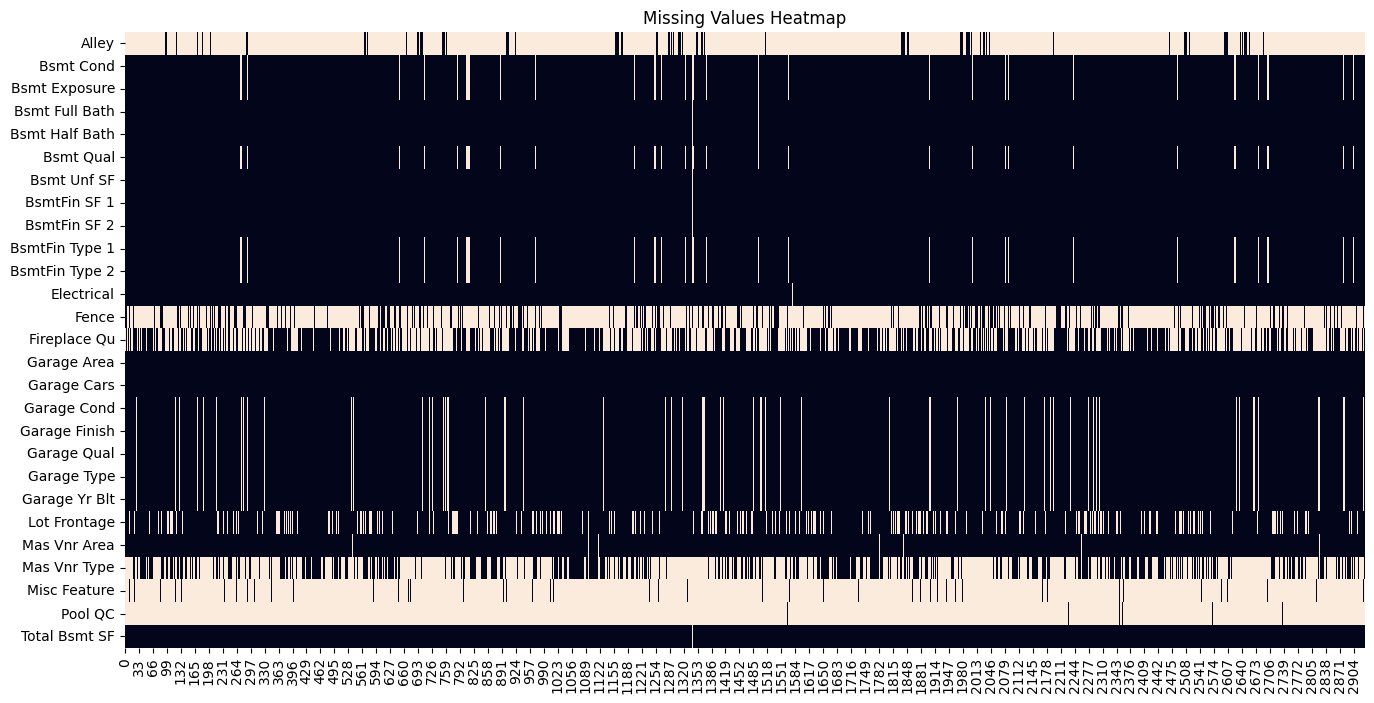

In [4]:
df_heatmap = df[sorted(cols_w_missing_values)].T # Transpose the DataFrame for easier visualization

plt.figure(figsize=(16, 8))
ax = sns.heatmap(df_heatmap.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show() 

This heatmap shows which values are missing for every column we identified (shown in a cream color).

This shows some interesting patterns like:
- Missing values that occur at the same time in groups (eg. columns that start with Bsmt and Garage)
- The single missing value for `Eletrical` looks completely random which might mean it was a typing mistake or something of the sort
- `Bsmt Full Bath` and `Bsmt Half Bath` missing values appear together in two different occasions.

Let's plot another heatmap to see the correlations between columns with missing values.

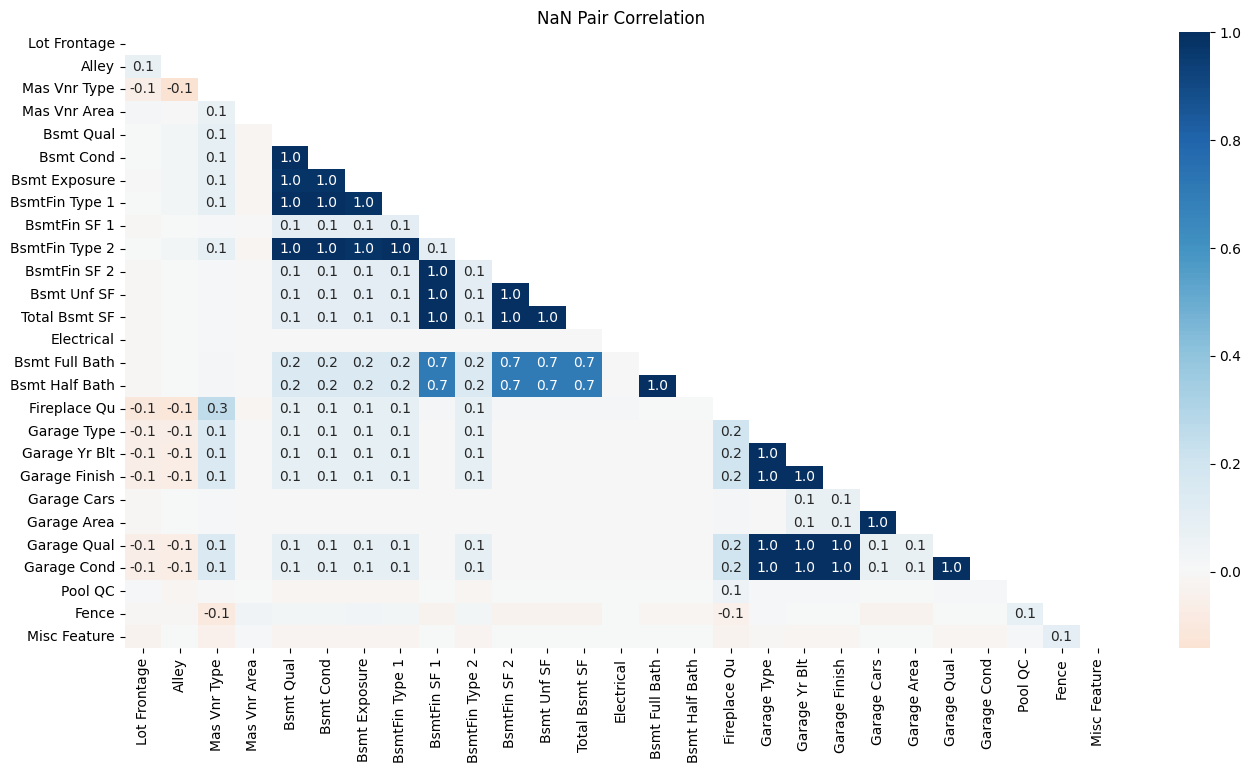

In [5]:
nan_pair__corr = df[cols_w_missing_values].isnull().corr()
mask = np.triu(np.ones_like(nan_pair__corr, dtype=bool))
annot_custom = nan_pair__corr.map(lambda v: f'{v:.1f}' if abs(v) > 0.05 else "")

plt.figure(figsize=(16, 8))
sns.heatmap(nan_pair__corr , mask=mask, cmap='RdBu', center=0, annot=annot_custom, fmt='')
plt.title("NaN Pair Correlation")
plt.show()

The correlation heatmap above also corroborates with the theory that there are a few groups of missing values like Bsmt and Garage.

_____


The documentation suggest that there are NaN values which signify the lack of presence of another variable, let's see if it occurs everytime.

In [6]:
def verify_structural_missingness(df, feature_name, quantitative_col, descriptive_cols):
    
    """
    Verifies if missing values in descriptive columns are structural 
    by checking if they align with a zero value in a quantitative column.
    """
    
    # Rows where the feature is not there (Count or Area == 0)
    absent_feature = df[df[quantitative_col] == 0] 
    
    # Check if all descriptive columns are correctly NaN for these rows
    all_null = absent_feature[descriptive_cols].isnull().all().all()
    
    # Identify mismatches (Garage Area is 0, but Garage Type is recorded)
    mismatches = absent_feature[absent_feature[descriptive_cols].notnull().any(axis=1)]
    
    print(f"--- Verification for {feature_name} ---")
    if all_null:
        print(f"SUCESS - All missing values appear to be Structural.")
    else:
        print(f"FAILED - Found {len(mismatches)} rows with potential data entry errors.")
    
    print(f"Total rows with 0 {feature_name}: {len(absent_feature)}\n")

In [7]:
verification_groups = {
    "Pools": {
        "quantitative": "Pool Area", 
        "descriptive": ["Pool QC"]
    },
    "Fireplaces": {
        "quantitative": "Fireplaces", 
        "descriptive": ["Fireplace Qu"]
    },
    "Garages": {
        "quantitative": "Garage Area", 
        "descriptive": ["Garage Type", "Garage Finish", "Garage Qual", "Garage Cond"]
    },
    "Basements": {
        "quantitative": "Total Bsmt SF", 
        "descriptive": ["Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"]
    },
    "Masonry Veneer": {
        "quantitative": "Mas Vnr Area", 
        "descriptive": ["Mas Vnr Type"]
    }
}

for feature, config in verification_groups.items():
    verify_structural_missingness(df, feature, config["quantitative"], config["descriptive"])

--- Verification for Pools ---
SUCESS - All missing values appear to be Structural.
Total rows with 0 Pools: 2917

--- Verification for Fireplaces ---
SUCESS - All missing values appear to be Structural.
Total rows with 0 Fireplaces: 1422

--- Verification for Garages ---
SUCESS - All missing values appear to be Structural.
Total rows with 0 Garages: 157

--- Verification for Basements ---
SUCESS - All missing values appear to be Structural.
Total rows with 0 Basements: 79

--- Verification for Masonry Veneer ---
FAILED - Found 3 rows with potential data entry errors.
Total rows with 0 Masonry Veneer: 1748



For Pools, Fireplaces, Garages and Basements there are definitely clear signs of Structural missing data classification. 

Masonry Veneer, in this case, is an interesting grouping because it doesn't work 100% like the others, let's try to see what is happening.

In [8]:
print("Type and Area missing together - ", df[(df['Mas Vnr Type'].isnull()) & (df['Mas Vnr Area'].isnull())].shape[0])

print("Type missing when Area == 0 - ", df[(df['Mas Vnr Type'].isnull()) & (df['Mas Vnr Area'] == 0)].shape[0])

Type and Area missing together -  23
Type missing when Area == 0 -  1745


In [9]:
df[~(df['Mas Vnr Type'].isnull()) & (df['Mas Vnr Area'] == 0)][['Mas Vnr Type', 'Mas Vnr Area']]

,Mas Vnr Type,Mas Vnr Area
1640,BrkFace,0.0
1740,BrkFace,0.0
1785,Stone,0.0


Mas Vnr Type has in total 1775 missing values, 1745 of those happen when Mas Vnr Area is 0, but there are 23 which are missing in both that seem to have no explanation.

There is also an interesting behaviour in the columns where Area is 0 but the Type is still referenced, when it probably shouldn't be.

----

For the Garages grouping, in the documentation there is no explicit meaning for the single missing value in the Garage Cars and Garage Area columns. 

Let' see if they happen they the Type is NaN (in this case, the documentation says a NaN = No Garage)

In [10]:
print("Garage Cars missing when Garage Type is NaN", df[(df['Garage Cars'].isnull()) & (df['Garage Cars'].isnull())].shape[0])

Garage Cars missing when Garage Type is NaN 1


In [11]:
print("Garage Area missing when Garage Type is NaN", df[(df['Garage Area'].isnull()) & (df['Garage Cars'].isnull())].shape[0])

Garage Area missing when Garage Type is NaN 1


For some of the Basement grouping columns there is the same problem with documentation not being clear enough, but inspecting the missing value heatmap, it seems to me that most of these columns have a value missing in the same row, which could mean a error of input in that specific column.

In [12]:
df[(df['BsmtFin SF 1'].isnull()) & (df['BsmtFin SF 2'].isnull()) & (df['Bsmt Unf SF'].isnull()) & (df['Total Bsmt SF'].isnull())
   & (df['Bsmt Full Bath'].isnull()) & (df['Bsmt Half Bath'].isnull())]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,1342,903230120,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


_____

For the Lot Frontage column there is still no explanation for the amount of missing values.

Let's first try to see if there's any significant correlation between Lot Frontage and the numerical features.

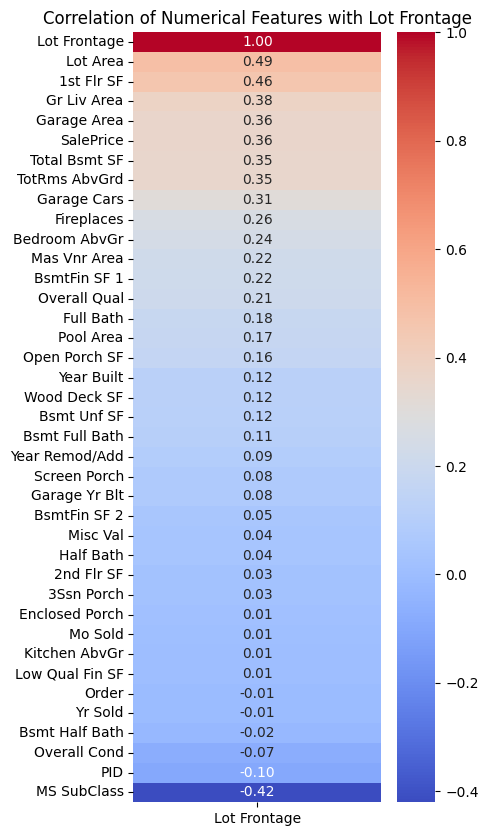

In [13]:
lot_corr = df.select_dtypes(include='number').corr()[['Lot Frontage']]
lot_corr = lot_corr.sort_values(by='Lot Frontage', ascending=False)

plt.figure(figsize=(4, 10))
sns.heatmap(lot_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Numerical Features with Lot Frontage')
plt.show()

The documentation says that Lot Frontage is a continuous variable that shows the Linear feet of street connected to property, with this information there are a few columns that might have correlation to it.

- Lot Area - Bigger lots might have more frontage
- Lot Config - Different lot configurations might have different configuration of frontage
- Lot Shape - The same reason mentioned above.
- Neighbourhood - Different neighbourhoods might have different frontages

Considering the correlation heatmap let's also verify:
- 1st Flr SF
- Gr Liv Area
- Garage Area
- MS SubClass

In [15]:
def check_mar_significance(df, target_col, features):
    """
    Tests if missingness in target_col is related to other features.
    Returns a dictionary of p-values.
    """
    results = {}
    
    df_temp = df.copy()
    df_temp['is_missing'] = df_temp[target_col].isnull().astype(int)
    
    missing_group = df_temp[df_temp['is_missing'] == 1]
    observed_group = df_temp[df_temp['is_missing'] == 0]

    for col in features:
        # Check if column is numerical or categorical
        if pd.api.types.is_numeric_dtype(df_temp[col]) and df_temp[col].nunique() > 10:
            # --- NUMERICAL: T-Test ---
            # We compare the distribution of the feature between missing and non-missing groups
            stat, p_val = stats.ttest_ind(
                missing_group[col].dropna(), 
                observed_group[col].dropna(), 
                equal_var=False
            )
            test_type = "T-Test"
        else:
            # --- CATEGORICAL: Chi-Square ---
            # We check if the proportion of missing values changes across categories
            contingency_table = pd.crosstab(df_temp['is_missing'], df_temp[col])
            chi2, p_val, dof, ex = stats.chi2_contingency(contingency_table)
            test_type = "Chi-Square"
            
        results[col] = {"p_value": round(p_val, 4), "test": test_type}

    return pd.DataFrame(results).T

features_to_check = [
    'Lot Area', 'Lot Shape', 'Lot Config', 'Neighborhood', 
    '1st Flr SF', 'Gr Liv Area', 'Garage Area', 'MS SubClass'
]

df['MS SubClass'] = df['MS SubClass'].astype(str)

p_values_df = check_mar_significance(df, 'Lot Frontage', features_to_check)
print(p_values_df.sort_values('p_value'))

             p_value        test
Lot Area         0.0      T-Test
Lot Shape        0.0  Chi-Square
Lot Config       0.0  Chi-Square
Neighborhood     0.0  Chi-Square
MS SubClass      0.0  Chi-Square
Gr Liv Area   0.0099      T-Test
Garage Area   0.0211      T-Test
1st Flr SF    0.0395      T-Test


Since $p < 0.05$ for every single feature, we can assume the missing values for Lot Frontage have correlation to other variables therefore it can be be classified as MAR.